# 01. Auditoría del dataset APTOS 2019

Este notebook realiza la auditoría inicial del conjunto APTOS 2019
utilizado para el modelo especializado en Retinopatía Diabética.

La auditoría se realiza exclusivamente sobre el conjunto etiquetado
compuesto por `train.csv` y `train_images/`.

El conjunto oficial `test_images/` no se utiliza para entrenamiento,
selección de modelo ni evaluación experimental debido a que `test.csv`
no contiene las etiquetas reales de diagnóstico.

Las clases consideradas son:

- 0: Sin Retinopatía Diabética
- 1: Retinopatía Diabética Leve
- 2: Retinopatía Diabética Moderada
- 3: Retinopatía Diabética Severa
- 4: Retinopatía Diabética Proliferativa


## 1. Configuración del entorno y rutas del dataset

Definición de las rutas del proyecto en Linux/WSL para el conjunto APTOS 2019 (`datasets/RD/aptos2019`), validación de existencia de los archivos clave (`train.csv`, `train_images`) y creación del directorio de resultados de auditoría (`results/RD/data_audit`).


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
from PIL import Image

PROJECT_ROOT = Path(
    "/mnt/c/Users/SeuNg720/Documents/TP1-RetiScan"
)
APTOS_ROOT = (
    PROJECT_ROOT
    / "datasets"
    / "RD"
    / "aptos2019"
)
RAW_DIR = APTOS_ROOT / "raw"
TRAIN_IMAGES_DIR = RAW_DIR / "train_images"
TEST_IMAGES_DIR = RAW_DIR / "test_images"
TRAIN_CSV = RAW_DIR / "train.csv"
TEST_CSV = RAW_DIR / "test.csv"
RESULTS_DIR = (
    PROJECT_ROOT
    / "results"
    / "RD"
    / "data_audit"
)
RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print("APTOS root:", APTOS_ROOT)
print("Train CSV existe:", TRAIN_CSV.exists())
print("Train images existe:", TRAIN_IMAGES_DIR.exists())
print("Results:", RESULTS_DIR)


APTOS root: /mnt/c/Users/SeuNg720/Documents/TP1-RetiScan/datasets/RD/aptos2019
Train CSV existe: True
Train images existe: True
Results: /mnt/c/Users/SeuNg720/Documents/TP1-RetiScan/results/RD/data_audit


## 2. Carga preliminar de tablas y exploración de dimensiones

Lectura de `train.csv` y `test.csv` oficial para verificar la estructura inicial de filas y columnas de cada subconjunto provisto en la competencia.


In [2]:
train_df = pd.read_csv(TRAIN_CSV)
official_test_df = pd.read_csv(TEST_CSV)

print("Train CSV:", train_df.shape)
print("Test CSV oficial:", official_test_df.shape)

display(train_df.head())
display(official_test_df.head())


Train CSV: (3662, 2)
Test CSV oficial: (1928, 1)


,id_code,diagnosis
0,000c1434d8d7,2
1,001639a390f0,4
2,0024cdab0c1e,1
3,002c21358ce6,0
4,005b95c28852,0


,id_code
0,0005cfc8afb6
1,003f0afdcd15
2,006efc72b638
3,00836aaacf06
4,009245722fa4


## 3. Verificación de columnas y distribución de diagnósticos

Inspección de las columnas disponibles en ambos conjuntos, comprobación de la ausencia de etiquetas diagnósticas en `test.csv` oficial, y cálculo de la distribución de frecuencias de los grados de Retinopatía Diabética (0 a 4) en `train.csv`.


In [3]:
print("Columnas train:")
print(train_df.columns.tolist())

print("\nColumnas test oficial:")
print(official_test_df.columns.tolist())

print("\nCantidad de registros etiquetados:")
print(len(train_df))

print("\nDistribución diagnosis:")
print(
    train_df["diagnosis"]
    .value_counts()
    .sort_index()
)


Columnas train:
['id_code', 'diagnosis']

Columnas test oficial:
['id_code']

Cantidad de registros etiquetados:
3662

Distribución diagnosis:
diagnosis
0    1805
1     370
2     999
3     193
4     295
Name: count, dtype: int64


## 4. Verificación de correspondencia entre etiquetas e imágenes

Se verifica que cada identificador presente en `train.csv` tenga una
imagen correspondiente dentro de `train_images/` y que no existan
imágenes adicionales sin registro en el archivo de etiquetas.

Esta comprobación permite detectar imágenes faltantes, registros sin
archivo asociado o archivos no contemplados en el CSV.


In [4]:
train_image_files = sorted(
    TRAIN_IMAGES_DIR.glob("*.png")
)
train_image_ids = {
    path.stem
    for path in train_image_files
}
csv_ids = set(
    train_df["id_code"]
    .astype(str)
)

print(
    "Registros en train.csv:",
    len(csv_ids)
)
print(
    "Imágenes PNG en train_images:",
    len(train_image_ids)
)

missing_images = (
    csv_ids
    - train_image_ids
)
extra_images = (
    train_image_ids
    - csv_ids
)

print(
    "\nRegistros CSV sin imagen:",
    len(missing_images)
)
print(
    "Imágenes sin registro CSV:",
    len(extra_images)
)


Registros en train.csv: 3662
Imágenes PNG en train_images: 3662

Registros CSV sin imagen: 0
Imágenes sin registro CSV: 0


### 4.1. Persistencia de discrepancias detectadas

Guardado preventivo de tablas con registros faltantes o archivos sin etiquetar en el directorio de resultados de auditoría.


In [5]:
missing_images_df = pd.DataFrame(
    {
        "id_code": sorted(
            missing_images
        )
    }
)
extra_images_df = pd.DataFrame(
    {
        "id_code": sorted(
            extra_images
        )
    }
)

missing_images_df.to_csv(
    RESULTS_DIR
    / "imagenes_faltantes.csv",
    index=False
)
extra_images_df.to_csv(
    RESULTS_DIR
    / "imagenes_sin_etiqueta.csv",
    index=False
)


## 5. Verificación de duplicados y valores nulos

Comprobación de unicidad a nivel de filas completas e identificadores de imagen (`id_code`), y cuantificación de datos ausentes (`NaN`) en cada columna.


In [6]:
print(
    "Filas duplicadas completas:",
    train_df.duplicated().sum()
)
print(
    "ID duplicados:",
    train_df["id_code"]
    .duplicated()
    .sum()
)
print(
    "\nValores nulos por columna:"
)
print(
    train_df.isna().sum()
)


Filas duplicadas completas: 0
ID duplicados: 0

Valores nulos por columna:
id_code      0
diagnosis    0
dtype: int64


### 3.1. Validación del rango de etiquetas de diagnóstico

Comprobación estricta de que las etiquetas diagnósticas pertenezcan exclusivamente al conjunto válido {0, 1, 2, 3, 4}, asegurando la ausencia de clases espurias o valores fuera de norma.


In [7]:
valid_labels = {
    0, 1, 2, 3, 4
}
observed_labels = set(
    train_df["diagnosis"]
    .unique()
)
invalid_labels = (
    observed_labels
    - valid_labels
)

print(
    "Etiquetas observadas:",
    sorted(observed_labels)
)
print(
    "Etiquetas inválidas:",
    sorted(invalid_labels)
)


Etiquetas observadas: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
Etiquetas inválidas: []


### 3.2. Consolidación y persistencia de la distribución de clases

Cálculo de frecuencias absolutas y relativas por grado de severidad clínica y guardado en `distribucion_clases_aptos2019.csv`.


In [8]:
class_names = {
    0: "Sin RD",
    1: "Leve",
    2: "Moderada",
    3: "Severa",
    4: "Proliferativa"
}
class_distribution = (
    train_df["diagnosis"]
    .value_counts()
    .sort_index()
    .rename_axis("diagnosis")
    .reset_index(
        name="cantidad"
    )
)
class_distribution[
    "clase"
] = class_distribution[
    "diagnosis"
].map(class_names)
class_distribution[
    "porcentaje"
] = (
    class_distribution[
        "cantidad"
    ]
    / len(train_df)
    * 100
)
class_distribution = (
    class_distribution[
        [
            "diagnosis",
            "clase",
            "cantidad",
            "porcentaje"
        ]
    ]
)

display(
    class_distribution.round(2)
)

class_distribution.to_csv(
    RESULTS_DIR
    / "distribucion_clases_aptos2019.csv",
    index=False
)


,diagnosis,clase,cantidad,porcentaje
0,0,Sin RD,1805,49.29
1,1,Leve,370,10.10
2,2,Moderada,999,27.28
3,3,Severa,193,5.27
4,4,Proliferativa,295,8.06


## 4. Verificación de integridad y características de las imágenes

Se comprueba que todas las imágenes etiquetadas puedan ser abiertas y
decodificadas correctamente.

Además, se registran sus dimensiones, relación de aspecto, modo de color
y formato con el objetivo de caracterizar la heterogeneidad visual del
dataset antes de establecer el procedimiento de preprocesamiento.


### 4.1. Decodificación exhaustiva y extracción de metadatos de imágenes

Iteración sobre las 3662 imágenes de `train_images` forzando la decodificación completa en memoria (`img.load()`) para detectar posibles archivos corruptos o ilegibles y capturar dimensiones espaciales, relación de aspecto, modo de color y formato.


In [9]:
image_audit_rows = []
corrupted_images = []

for i, image_path in enumerate(
    train_image_files,
    start=1
):
    try:
        with Image.open(image_path) as img:
            # Fuerza la decodificación completa de la imagen
            img.load()
            width, height = img.size
            image_audit_rows.append(
                {
                    "id_code": image_path.stem,
                    "image_name": image_path.name,
                    "width": width,
                    "height": height,
                    "aspect_ratio": (
                        width / height
                    ),
                    "mode": img.mode,
                    "format": img.format
                }
            )
    except Exception as e:
        corrupted_images.append(
            {
                "id_code": image_path.stem,
                "image_name": image_path.name,
                "error": str(e)
            }
        )


### 4.2. Consolidación del estado de integridad

Construcción de DataFrames a partir de los registros de auditoría y cuantificación de imágenes procesadas exitosamente versus archivos dañados.


In [10]:
image_audit_df = pd.DataFrame(
    image_audit_rows
)
corrupted_images_df = pd.DataFrame(
    corrupted_images
)

print(
    "Imágenes analizadas correctamente:",
    len(image_audit_df)
)
print(
    "Imágenes con error:",
    len(corrupted_images_df)
)


Imágenes analizadas correctamente: 3662
Imágenes con error: 0


### 4.3. Resumen estadístico de resolución y relación de aspecto

Estadísticas descriptivas (media, desviación estándar, percentiles, mínimos y máximos) para el ancho, alto y relación de aspecto de las imágenes analizadas.


In [11]:
print("Resumen de dimensiones:")
display(
    image_audit_df[
        [
            "width",
            "height",
            "aspect_ratio"
        ]
    ].describe()
)


Resumen de dimensiones:


,width,height,aspect_ratio
count,3662.000000,3662.000000,3662.000000
mean,2015.176679,1526.830147,1.283818
std,884.301940,542.663120,0.182116
min,474.000000,358.000000,1.000000
25%,1050.000000,1050.000000,1.000000
50%,2144.000000,1536.000000,1.333333
75%,2588.000000,1958.000000,1.391705
max,4288.000000,2848.000000,1.505618


### 4.4. Distribución de modos de color y formatos de archivo

Verificación de la uniformidad en canales cromáticos (RGB) y codificación de imagen (PNG).


In [12]:
print("Modos de color:")
print(
    image_audit_df["mode"]
    .value_counts()
)

print(
    "\nFormatos:"
)
print(
    image_audit_df["format"]
    .value_counts()
)


Modos de color:
mode
RGB    3662
Name: count, dtype: int64

Formatos:
format
PNG    3662
Name: count, dtype: int64


### 4.5. Análisis de heterogeneidad de resoluciones

Agrupación por pares (ancho, alto) para dimensionar la dispersión en tamaños de imagen y listar las 20 resoluciones más frecuentes en el conjunto de entrenamiento.


In [13]:
resolution_distribution = (
    image_audit_df
    .groupby(
        [
            "width",
            "height"
        ]
    )
    .size()
    .reset_index(
        name="cantidad"
    )
    .sort_values(
        "cantidad",
        ascending=False
    )
)

print(
    "Cantidad de resoluciones diferentes:",
    len(resolution_distribution)
)
display(
    resolution_distribution.head(20)
)


Cantidad de resoluciones diferentes: 17


,width,height,cantidad
3,1050,1050,974
11,2416,1736,638
12,2588,1958,533
14,3216,2136,410
8,2048,1536,351
2,819,614,287
15,3388,2588,141
6,1504,1000,92
7,1844,1226,61
16,4288,2848,52


### 4.6. Exploración de casos extremos de resolución

Inspección de las imágenes con dimensiones mínimas y máximas en ancho para identificar posibles casos atípicos o desproporcionados.


In [14]:
print("Imagen con menor ancho:")
display(
    image_audit_df
    .sort_values("width")
    .head(5)
)

print(
    "\nImagen con mayor ancho:"
)
display(
    image_audit_df
    .sort_values(
        "width",
        ascending=False
    )
    .head(5)
)


Imagen con menor ancho:


,id_code,image_name,width,height,aspect_ratio,mode,format
1800,7efc91af4ae6,7efc91af4ae6.png,474,358,1.324022,RGB,PNG
642,2d552318eb07,2d552318eb07.png,474,358,1.324022,RGB,PNG
3139,d9bbdc33db83,d9bbdc33db83.png,640,480,1.333333,RGB,PNG
76,06024377d573,06024377d573.png,640,480,1.333333,RGB,PNG
3166,dbb2c63f6f08,dbb2c63f6f08.png,640,480,1.333333,RGB,PNG



Imagen con mayor ancho:


,id_code,image_name,width,height,aspect_ratio,mode,format
3357,e9286ddf6ffe,e9286ddf6ffe.png,4288,2848,1.505618,RGB,PNG
3276,e38f3a65b02b,e38f3a65b02b.png,4288,2848,1.505618,RGB,PNG
572,28824d12d31d,28824d12d31d.png,4288,2848,1.505618,RGB,PNG
3370,e9ff9352ccb3,e9ff9352ccb3.png,4288,2848,1.505618,RGB,PNG
120,093a42649c29,093a42649c29.png,4288,2848,1.505618,RGB,PNG


### 4.7. Persistencia de reportes de auditoría visual

Almacenamiento de metadatos completos, lista de archivos corruptos y tabla de distribución de resoluciones en el directorio de resultados.


In [15]:
image_audit_df.to_csv(
    RESULTS_DIR
    / "auditoria_integridad_imagenes.csv",
    index=False
)
corrupted_images_df.to_csv(
    RESULTS_DIR
    / "imagenes_corruptas.csv",
    index=False
)
resolution_distribution.to_csv(
    RESULTS_DIR
    / "distribucion_resoluciones.csv",
    index=False
)

print("Auditoría guardada exitosamente en:", RESULTS_DIR)


Auditoría guardada exitosamente en: /mnt/c/Users/SeuNg720/Documents/TP1-RetiScan/results/RD/data_audit


## 5. Detección de imágenes duplicadas por contenido

Aunque los identificadores `id_code` son únicos, se verifica si existen
imágenes con contenido binario idéntico asociadas a identificadores
diferentes.

Esta comprobación se realiza antes de generar las particiones
Train, Validation y Test con el objetivo de evitar posibles fugas de
información entre subconjuntos.

In [26]:
import hashlib

hash_rows = []
for i, image_path in enumerate(
    train_image_files,
    start=1
):
    sha256 = hashlib.sha256()
    with open(image_path, "rb") as f:
        for chunk in iter(
            lambda: f.read(1024 * 1024),
            b""
        ):
            sha256.update(chunk)
    hash_rows.append(
        {
            "id_code": image_path.stem,
            "image_name": image_path.name,
            "sha256": sha256.hexdigest()
        }
    )
    if (
        i % 500 == 0
        or i == len(train_image_files)
    ):
        print(
            f"Procesadas: {i}/{len(train_image_files)}"
        )
image_hash_df = pd.DataFrame(
    hash_rows
)

Procesadas: 500/3662
Procesadas: 1000/3662
Procesadas: 1500/3662
Procesadas: 2000/3662
Procesadas: 2500/3662
Procesadas: 3000/3662
Procesadas: 3500/3662
Procesadas: 3662/3662


### 5.1. Identificación y cuantificación de imágenes duplicadas

Filtrado y visualización de registros cuyos hashes SHA-256 coincidan en más de un identificador para evaluar colisiones binarias exactas en el conjunto de entrenamiento.

In [27]:
duplicate_hash_mask = (
    image_hash_df["sha256"]
    .duplicated(
        keep=False
    )
)
duplicate_images_df = (
    image_hash_df[
        duplicate_hash_mask
    ]
    .sort_values(
        "sha256"
    )
    .reset_index(
        drop=True
    )
)
print(
    "Imágenes involucradas en duplicados exactos:",
    len(duplicate_images_df)
)
print(
    "Hashes duplicados distintos:",
    duplicate_images_df[
        "sha256"
    ].nunique()
)
display(
    duplicate_images_df
)

Imágenes involucradas en duplicados exactos: 251
Hashes duplicados distintos: 123


,id_code,image_name,sha256
0,c1c8550508e0,c1c8550508e0.png,016d1670c19024f2c7de31378a660a5c7fc9d6caea2461...
1,530d78467615,530d78467615.png,016d1670c19024f2c7de31378a660a5c7fc9d6caea2461...
2,fda39982a810,fda39982a810.png,022b0e0373dd1ee8b134bc3393070e450ab2ba01f91d4b...
3,0ac436400db4,0ac436400db4.png,022b0e0373dd1ee8b134bc3393070e450ab2ba01f91d4b...
4,9e3510963315,9e3510963315.png,045ca0250e166bd98033075cd876adcaa7b9953c9a6c94...
...,...,...,...
246,a8b637abd96b,a8b637abd96b.png,f944186145653418c0ada62e23fc9fd226a8ee9788e163...
247,33105f9b3a04,33105f9b3a04.png,fa85dd94609764b5a27f409537d606b5214dace3c096f3...
248,111898ab463d,111898ab463d.png,fa85dd94609764b5a27f409537d606b5214dace3c096f3...
249,1c6d119c3d70,1c6d119c3d70.png,ff6a53000a5ee301d26cec3d6e8afb90bf274d7df0920a...


### 5.2. Persistencia del reporte de imágenes duplicadas

Guardado preventivo del resultado de la detección de duplicados exactos en el directorio de auditoría.

In [36]:
duplicate_images_df.to_csv(
    RESULTS_DIR
    / "duplicados_exactos_imagenes.csv",
    index=False
)

## 6. Consistencia de etiquetas entre imágenes duplicadas

Se analiza si las imágenes con contenido binario idéntico presentan la
misma etiqueta de severidad de Retinopatía Diabética.

La presencia de imágenes idénticas con etiquetas diferentes indicaría
una inconsistencia de etiquetado que debe resolverse antes de generar
las particiones experimentales.

In [37]:
duplicate_labeled_df = (
    duplicate_images_df
    .merge(
        train_df[
            [
                "id_code",
                "diagnosis"
            ]
        ],
        on="id_code",
        how="left"
    )
)
display(
    duplicate_labeled_df.head(20)
)

,id_code,image_name,sha256,diagnosis
0,c1c8550508e0,c1c8550508e0.png,016d1670c19024f2c7de31378a660a5c7fc9d6caea2461...,2
1,530d78467615,530d78467615.png,016d1670c19024f2c7de31378a660a5c7fc9d6caea2461...,2
2,fda39982a810,fda39982a810.png,022b0e0373dd1ee8b134bc3393070e450ab2ba01f91d4b...,3
3,0ac436400db4,0ac436400db4.png,022b0e0373dd1ee8b134bc3393070e450ab2ba01f91d4b...,2
4,9e3510963315,9e3510963315.png,045ca0250e166bd98033075cd876adcaa7b9953c9a6c94...,4
5,b187b3c93afb,b187b3c93afb.png,045ca0250e166bd98033075cd876adcaa7b9953c9a6c94...,2
6,3ca637fddd56,3ca637fddd56.png,04bbfed5d2cd875ea96ebecb46ec678ac5de34129bc0db...,4
7,3b4a5fcbe5e0,3b4a5fcbe5e0.png,04bbfed5d2cd875ea96ebecb46ec678ac5de34129bc0db...,4
8,43fb6eda9b97,43fb6eda9b97.png,099293bd82c9d96b44b05726a1c57870b3cbf97e71f343...,2
9,e4e343eaae2a,e4e343eaae2a.png,099293bd82c9d96b44b05726a1c57870b3cbf97e71f343...,2


### 6.1. Agrupamiento y resumen por hash de imágenes duplicadas

Consolidación de identificadores de imagen y diagnósticos asociados a cada hash único para cuantificar la multiplicidad y detectar posibles discrepancias de clase dentro de un mismo grupo.

In [38]:
duplicate_groups_summary = (
    duplicate_labeled_df
    .groupby("sha256")
    .agg(
        cantidad_imagenes=(
            "id_code",
            "size"
        ),
        cantidad_etiquetas=(
            "diagnosis",
            "nunique"
        ),
        etiquetas=(
            "diagnosis",
            lambda x: sorted(
                x.unique().tolist()
            )
        ),
        ids=(
            "id_code",
            lambda x: list(x)
        )
    )
    .reset_index()
)

### 6.2. Clasificación de grupos según consistencia diagnóstica

Comprobación de grupos de imágenes duplicadas con diagnóstico unánime versus grupos con etiquetas contradictorias.

In [39]:
consistent_duplicate_groups = (
    duplicate_groups_summary[
        duplicate_groups_summary[
            "cantidad_etiquetas"
        ] == 1
    ]
)
conflicting_duplicate_groups = (
    duplicate_groups_summary[
        duplicate_groups_summary[
            "cantidad_etiquetas"
        ] > 1
    ]
)
print(
    "Grupos duplicados totales:",
    len(duplicate_groups_summary)
)
print(
    "Grupos con etiqueta consistente:",
    len(consistent_duplicate_groups)
)
print(
    "Grupos con etiquetas conflictivas:",
    len(conflicting_duplicate_groups)
)

Grupos duplicados totales: 123
Grupos con etiqueta consistente: 93
Grupos con etiquetas conflictivas: 30


### 6.3. Inspección de grupos duplicados con etiquetas conflictivas

Visualización de los grupos de imágenes con contenido idéntico que presentan más de un diagnóstico asignado.

In [40]:
display(
    conflicting_duplicate_groups
)

,sha256,cantidad_imagenes,cantidad_etiquetas,etiquetas,ids
1,022b0e0373dd1ee8b134bc3393070e450ab2ba01f91d4b...,2,2,"[2, 3]","[fda39982a810, 0ac436400db4]"
2,045ca0250e166bd98033075cd876adcaa7b9953c9a6c94...,2,2,"[2, 4]","[9e3510963315, b187b3c93afb]"
8,0edc485466e1fc7ff1f7b4206f1707260f2f791d0693bc...,2,2,"[2, 3]","[521d3e264d71, fe0fc67c7980]"
10,1924764ef3f37f79d86e17ec57c24fcda433b1e1745748...,2,2,"[2, 4]","[2df07eb5779f, b91ef82e723a]"
18,2a6ef650a496f334a9634d69b0cf14dcb0db075d49776d...,2,2,"[1, 4]","[7005be54cab1, 3ee4841936ef]"
23,356d9ab05fbaff55feb696f83cbf012019fcf6d2f1b817...,2,2,"[0, 1]","[30cab14951ac, c546670d9684]"
24,36b368b0863842f82c8b38cb343b94ef81232cc4491286...,2,2,"[1, 2]","[35aa7f5c2ec0, 1c4d87baaffc]"
26,387028c6180af30126540dfb2c0038775da7644f398aa3...,2,2,"[2, 4]","[ab50123abadb, 80964d8e0863]"
30,405fb8cfa28dafb173a7e5b76c55390dd27bad3e70bc0f...,2,2,"[0, 1]","[f066db7a2efe, 278aa860dffd]"
37,4e7b24470e31e2c6fb2e8bc723c98e225ca9f9c80a1f39...,2,2,"[2, 3]","[6253f23229b1, 76cfe8967f7d]"


### 6.4. Aislamiento de imágenes individuales involucradas en conflictos

Filtrado detallado de todas las imágenes individuales cuyos hashes presentan discordancia de etiquetas diagnósticas.

In [41]:
conflicting_hashes = set(
    conflicting_duplicate_groups[
        "sha256"
    ]
)
conflicting_images_df = (
    duplicate_labeled_df[
        duplicate_labeled_df[
            "sha256"
        ].isin(
            conflicting_hashes
        )
    ]
    .sort_values(
        [
            "sha256",
            "diagnosis"
        ]
    )
    .reset_index(
        drop=True
    )
)
print(
    "Imágenes involucradas en conflictos:",
    len(conflicting_images_df)
)
display(
    conflicting_images_df
)

Imágenes involucradas en conflictos: 62


,id_code,image_name,sha256,diagnosis
0,0ac436400db4,0ac436400db4.png,022b0e0373dd1ee8b134bc3393070e450ab2ba01f91d4b...,2
1,fda39982a810,fda39982a810.png,022b0e0373dd1ee8b134bc3393070e450ab2ba01f91d4b...,3
2,b187b3c93afb,b187b3c93afb.png,045ca0250e166bd98033075cd876adcaa7b9953c9a6c94...,2
3,9e3510963315,9e3510963315.png,045ca0250e166bd98033075cd876adcaa7b9953c9a6c94...,4
4,521d3e264d71,521d3e264d71.png,0edc485466e1fc7ff1f7b4206f1707260f2f791d0693bc...,2
...,...,...,...,...
57,ea15a290eb96,ea15a290eb96.png,ebae39b7e639c64e51a8ebe01e85a047542a1bc80468d4...,1
58,e4151feb8443,e4151feb8443.png,ec008b381160f16d4bc7fd07f00eed5aedcf150c3f1fb7...,2
59,46cdc8b685bd,46cdc8b685bd.png,ec008b381160f16d4bc7fd07f00eed5aedcf150c3f1fb7...,4
60,42985aa2e32f,42985aa2e32f.png,f68d4db7f03892f9898ca5f5189e334a05e3966fbe7c94...,0


### 6.5. Persistencia de reportes de consistencia de duplicados

Almacenamiento del resumen de grupos duplicados y de la lista de imágenes con etiquetas conflictivas en el directorio de resultados.

In [42]:
duplicate_groups_summary.to_csv(
    RESULTS_DIR
    / "resumen_grupos_duplicados.csv",
    index=False
)
conflicting_images_df.to_csv(
    RESULTS_DIR
    / "duplicados_con_etiquetas_conflictivas.csv",
    index=False
)

## 7. Análisis de duplicados con etiquetas conflictivas

Se identificaron imágenes con contenido binario idéntico asociadas a
etiquetas de severidad diferentes.

Debido a que no existe información adicional que permita determinar cuál
de las etiquetas es clínicamente correcta, estos grupos se consideran
ambiguos y no se asigna arbitrariamente una etiqueta.

Antes de excluirlos del conjunto experimental se cuantifica su
composición y su impacto sobre la distribución de clases.

In [43]:
print(
    "Grupos conflictivos:",
    len(conflicting_duplicate_groups)
)
print(
    "Imágenes involucradas en conflictos:",
    len(conflicting_images_df)
)

Grupos conflictivos: 30
Imágenes involucradas en conflictos: 62


### 7.1. Patrones y combinaciones de etiquetas en conflicto

Frecuencia de las combinaciones diagnósticas discordantes para determinar si los desacuerdos ocurren predominantemente entre grados adyacentes de severidad o entre categorías clínicamente distantes.

In [44]:
conflict_patterns = (
    conflicting_duplicate_groups[
        "etiquetas"
    ]
    .astype(str)
    .value_counts()
    .rename_axis(
        "combinacion_etiquetas"
    )
    .reset_index(
        name="cantidad_grupos"
    )
)
display(
    conflict_patterns
)

,combinacion_etiquetas,cantidad_grupos
0,"[2, 3]",9
1,"[2, 4]",8
2,"[1, 2]",5
3,"[0, 1]",4
4,"[3, 4]",3
5,"[1, 4]",1


### 7.2. Distribución de imágenes conflictivas por clase clínica

Cuantificación de las imágenes involucradas en inconsistencias diagnósticas según cada grado de severidad de Retinopatía Diabética.

In [45]:
conflicting_class_distribution = (
    conflicting_images_df[
        "diagnosis"
    ]
    .value_counts()
    .sort_index()
    .rename_axis(
        "diagnosis"
    )
    .reset_index(
        name="cantidad_imagenes"
    )
)
conflicting_class_distribution[
    "clase"
] = conflicting_class_distribution[
    "diagnosis"
].map(
    class_names
)
display(
    conflicting_class_distribution
)

,diagnosis,cantidad_imagenes,clase
0,0,4,Sin RD
1,1,10,Leve
2,2,23,Moderada
3,3,13,Severa
4,4,12,Proliferativa


## 8. Construcción propuesta del conjunto limpio

Simulación de la política de depuración del conjunto de entrenamiento: asociación de hashes criptográficos a las observaciones originales, remoción total de grupos con etiquetas conflictivas y deduplicación de imágenes consistentes conservando un único representante.

### 8.1. Incorporación del hash SHA-256 al conjunto de datos

Cruce del identificador hash con la tabla de entrenamiento `train_df` para mapear cada registro con su contenido binario.

In [46]:
train_with_hash_df = (
    train_df
    .merge(
        image_hash_df[
            [
                "id_code",
                "sha256"
            ]
        ],
        on="id_code",
        how="left"
    )
)

### 8.2. Identificación y exclusión de grupos conflictivos

Aislamiento de los hashes correspondientes a grupos duplicados con etiquetas contradictorias y filtrado completo de dichas observaciones en el DataFrame.

In [47]:
conflicting_hashes = set(
    conflicting_duplicate_groups[
        "sha256"
    ]
)

non_conflicting_df = (
    train_with_hash_df[
        ~train_with_hash_df[
            "sha256"
        ].isin(
            conflicting_hashes
        )
    ]
    .copy()
)
print(
    "Antes:",
    len(train_with_hash_df)
)
print(
    "Después de eliminar grupos conflictivos:",
    len(non_conflicting_df)
)

Antes: 3662
Después de eliminar grupos conflictivos: 3600


### 8.3. Deduplicación de imágenes idénticas consistentes

Eliminación de copias redundantes dentro de los grupos con etiqueta unánime, reteniendo únicamente el primer ejemplar de cada contenido binario para evitar sobre-representación.

In [50]:
clean_df = (
    non_conflicting_df
    .sort_values(
        ["sha256", "id_code"]
    )
    .drop_duplicates(
        subset="sha256",
        keep="first"
    )
    .sort_values("id_code")
    .reset_index(drop=True)
)

print(
    "Imágenes originales:",
    len(train_df)
)

print(
    "Imágenes limpias finales:",
    len(clean_df)
)

print(
    "Imágenes excluidas en total:",
    len(train_df) - len(clean_df)
)

Imágenes originales: 3662
Imágenes limpias finales: 3504
Imágenes excluidas en total: 158


### 8.4. Distribución de clases en el conjunto limpio depurado

Evaluación de la proporción y balance de las 5 categorías diagnósticas tras la aplicación de la política de depuración y deduplicación.

In [49]:
clean_class_distribution = (
    clean_df[
        "diagnosis"
    ]
    .value_counts()
    .sort_index()
    .rename_axis(
        "diagnosis"
    )
    .reset_index(
        name="cantidad"
    )
)
clean_class_distribution[
    "clase"
] = clean_class_distribution[
    "diagnosis"
].map(
    class_names
)
clean_class_distribution[
    "porcentaje"
] = (
    clean_class_distribution[
        "cantidad"
    ]
    / len(clean_df)
    * 100
)
display(
    clean_class_distribution
    .round(2)
)

,diagnosis,cantidad,clase,porcentaje
0,0,1796,Sin RD,51.26
1,1,338,Leve,9.65
2,2,922,Moderada,26.31
3,3,177,Severa,5.05
4,4,271,Proliferativa,7.73


## 9. Trazabilidad de registros excluidos

Se documentan explícitamente las observaciones excluidas durante la
depuración del dataset, diferenciando entre grupos con etiquetas
conflictivas y copias redundantes pertenecientes a grupos con
diagnóstico consistente.

Esta trazabilidad permite reproducir la construcción del conjunto
experimental limpio sin modificar los archivos originales de APTOS 2019.

In [51]:
conflicting_ids = set(
    conflicting_images_df["id_code"]
)
clean_ids = set(
    clean_df["id_code"]
)
exclusion_rows = []
for _, row in train_with_hash_df.iterrows():
    id_code = row["id_code"]
    if id_code in conflicting_ids:
        reason = "conflicting_duplicate_label"
    elif id_code not in clean_ids:
        reason = "redundant_consistent_duplicate"
    else:
        continue
    exclusion_rows.append(
        {
            "id_code": id_code,
            "diagnosis": int(row["diagnosis"]),
            "sha256": row["sha256"],
            "exclusion_reason": reason
        }
    )
excluded_df = pd.DataFrame(
    exclusion_rows
)
display(
    excluded_df[
        "exclusion_reason"
    ].value_counts()
)
print(
    "Total excluidas:",
    len(excluded_df)
)

exclusion_reason
redundant_consistent_duplicate    96
conflicting_duplicate_label       62
Name: count, dtype: int64

Total excluidas: 158


### 9.1. Persistencia de registros excluidos

Guardado del registro de observaciones descartadas y sus causas de depuración en el directorio de resultados de auditoría.

In [52]:
EXCLUDED_PATH = (
    RESULTS_DIR
    / "aptos2019_registros_excluidos.csv"
)

excluded_df.to_csv(
    EXCLUDED_PATH,
    index=False
)

print(
    "Registros excluidos guardados en:",
    EXCLUDED_PATH
)

Registros excluidos guardados en: /mnt/c/Users/SeuNg720/Documents/TP1-RetiScan/results/RD/data_audit/aptos2019_registros_excluidos.csv


## 10. Impacto de la depuración sobre la distribución de clases

Se compara la distribución original del conjunto etiquetado de APTOS 2019
con la distribución obtenida después de eliminar los grupos duplicados con
etiquetas conflictivas y las copias redundantes de los grupos consistentes.

El objetivo es cuantificar el efecto de la depuración sobre cada grado de
Retinopatía Diabética y comprobar que todas las categorías continúan
representadas en el conjunto experimental.

In [53]:
original_counts = (
    train_df["diagnosis"]
    .value_counts()
    .sort_index()
)
clean_counts = (
    clean_df["diagnosis"]
    .value_counts()
    .sort_index()
)
distribution_comparison = pd.DataFrame(
    {
        "diagnosis": original_counts.index,
        "clase": [
            class_names[i]
            for i in original_counts.index
        ],
        "original": original_counts.values,
        "limpio": clean_counts.values
    }
)
distribution_comparison[
    "excluidas"
] = (
    distribution_comparison["original"]
    - distribution_comparison["limpio"]
)
distribution_comparison[
    "reduccion_pct"
] = (
    distribution_comparison["excluidas"]
    / distribution_comparison["original"]
    * 100
)

display(
    distribution_comparison
)
print(
    "Total de observaciones excluidas:",
    distribution_comparison[
        "excluidas"
    ].sum()
)

,diagnosis,clase,original,limpio,excluidas,reduccion_pct
0,0,Sin RD,1805,1796,9,0.498615
1,1,Leve,370,338,32,8.648649
2,2,Moderada,999,922,77,7.707708
3,3,Severa,193,177,16,8.290155
4,4,Proliferativa,295,271,24,8.135593


Total de observaciones excluidas: 158


### 10.1. Comparación porcentual antes y después de la depuración

Evaluación del impacto relativo de las exclusiones sobre la proporción de cada clase para verificar que el balance original del dataset no haya sufrido distorsiones significativas.

In [54]:
distribution_comparison[
    "porcentaje_original"
] = (
    distribution_comparison["original"]
    / len(train_df)
    * 100
)
distribution_comparison[
    "porcentaje_limpio"
] = (
    distribution_comparison["limpio"]
    / len(clean_df)
    * 100
)
display(
    distribution_comparison[
        [
            "diagnosis",
            "clase",
            "original",
            "limpio",
            "excluidas",
            "reduccion_pct",
            "porcentaje_original",
            "porcentaje_limpio"
        ]
    ].round(2)
)

,diagnosis,clase,original,limpio,excluidas,reduccion_pct,porcentaje_original,porcentaje_limpio
0,0,Sin RD,1805,1796,9,0.50,49.29,51.26
1,1,Leve,370,338,32,8.65,10.10,9.65
2,2,Moderada,999,922,77,7.71,27.28,26.31
3,3,Severa,193,177,16,8.29,5.27,5.05
4,4,Proliferativa,295,271,24,8.14,8.06,7.73


### 10.2. Persistencia de la comparativa de distribución

Almacenamiento de la tabla consolidada de impacto y balance de clases en el directorio de resultados de auditoría.

In [55]:
DISTRIBUTION_COMPARISON_PATH = (
    RESULTS_DIR
    / "comparacion_distribucion_antes_despues.csv"
)
distribution_comparison.to_csv(
    DISTRIBUTION_COMPARISON_PATH,
    index=False
)
print(
    "Comparación guardada en:",
    DISTRIBUTION_COMPARISON_PATH
)

Comparación guardada en: /mnt/c/Users/SeuNg720/Documents/TP1-RetiScan/results/RD/data_audit/comparacion_distribucion_antes_despues.csv


## 11. Verificación final del conjunto limpio

Se realizan comprobaciones automáticas sobre el conjunto depurado para
verificar que la política de limpieza se haya aplicado correctamente.

Se comprueba que:

- el número final de observaciones sea el esperado;
- no existan identificadores duplicados;
- no existan contenidos binarios duplicados;
- no existan valores nulos;
- las cinco categorías diagnósticas permanezcan representadas;
- ningún grupo previamente identificado como conflictivo permanezca
  dentro del conjunto limpio.

In [56]:
print(
    "Cantidad final:",
    len(clean_df)
)
print(
    "IDs únicos:",
    clean_df["id_code"].is_unique
)
print(
    "Hashes únicos:",
    clean_df["sha256"].is_unique
)
print(
    "Valores nulos:",
    int(
        clean_df.isna().sum().sum()
    )
)
print(
    "Clases presentes:",
    sorted(
        clean_df["diagnosis"]
        .unique()
        .tolist()
    )
)
conflicting_hashes_remaining = (
    clean_df["sha256"]
    .isin(conflicting_hashes)
    .sum()
)
print(
    "Hashes conflictivos restantes:",
    conflicting_hashes_remaining
)

Cantidad final: 3504
IDs únicos: True
Hashes únicos: True
Valores nulos: 0
Clases presentes: [0, 1, 2, 3, 4]
Hashes conflictivos restantes: 0


### 11.1. Aserciones de integridad

Validación estricta mediante aserciones para garantizar que todas las condiciones metodológicas de unicidad, completitud, balance y eliminación de inconsistencias se cumplan sin excepciones.

In [57]:
assert len(clean_df) == 3504
assert clean_df["id_code"].is_unique
assert clean_df["sha256"].is_unique
assert clean_df.isna().sum().sum() == 0
assert set(
    clean_df["diagnosis"].unique()
) == {
    0, 1, 2, 3, 4
}
assert not clean_df[
    "sha256"
].isin(
    conflicting_hashes
).any()
assert (
    len(train_df)
    - len(clean_df)
) == 158
assert (
    distribution_comparison[
        "excluidas"
    ].sum()
) == 158
print(
    "Todas las verificaciones del conjunto limpio fueron superadas."
)

Todas las verificaciones del conjunto limpio fueron superadas.


### 11.2. Verificación de correspondencia física de las 3504 imágenes

Comprobación de la existencia física en disco de cada uno de los archivos de imagen asociados a los identificadores sobrevivientes en el conjunto depurado.

In [58]:
clean_df[
    "image_path"
] = clean_df[
    "id_code"
].apply(
    lambda x:
        str(
            TRAIN_IMAGES_DIR
            / f"{x}.png"
        )
)
clean_df[
    "image_exists"
] = clean_df[
    "image_path"
].apply(
    lambda x:
        Path(x).exists()
)
print(
    "Imágenes limpias esperadas:",
    len(clean_df)
)
print(
    "Imágenes encontradas:",
    int(
        clean_df[
            "image_exists"
        ].sum()
    )
)
print(
    "Imágenes faltantes:",
    int(
        (~clean_df[
            "image_exists"
        ]).sum()
    )
)

Imágenes limpias esperadas: 3504
Imágenes encontradas: 3504
Imágenes faltantes: 0


### 11.3. Aserción de correspondencia física

Confirmación explícita mediante aserción de que la totalidad de las imágenes del conjunto limpio residen efectivamente en el directorio de entrenamiento.

In [59]:
assert clean_df[
    "image_exists"
].all()
print(
    "Correspondencia física del conjunto limpio: OK"
)

Correspondencia física del conjunto limpio: OK


## 12. Exploración visual del conjunto limpio

Se realiza una inspección visual de muestras pertenecientes a las cinco
categorías diagnósticas después de aplicar la política de depuración.

La exploración permite identificar variaciones en iluminación, contraste,
resolución, relación de aspecto, presencia de bordes negros y características
del campo retinal antes de definir el procedimiento de preprocesamiento.

Las imágenes excluidas por duplicación o conflicto de etiquetas no participan
en esta revisión.

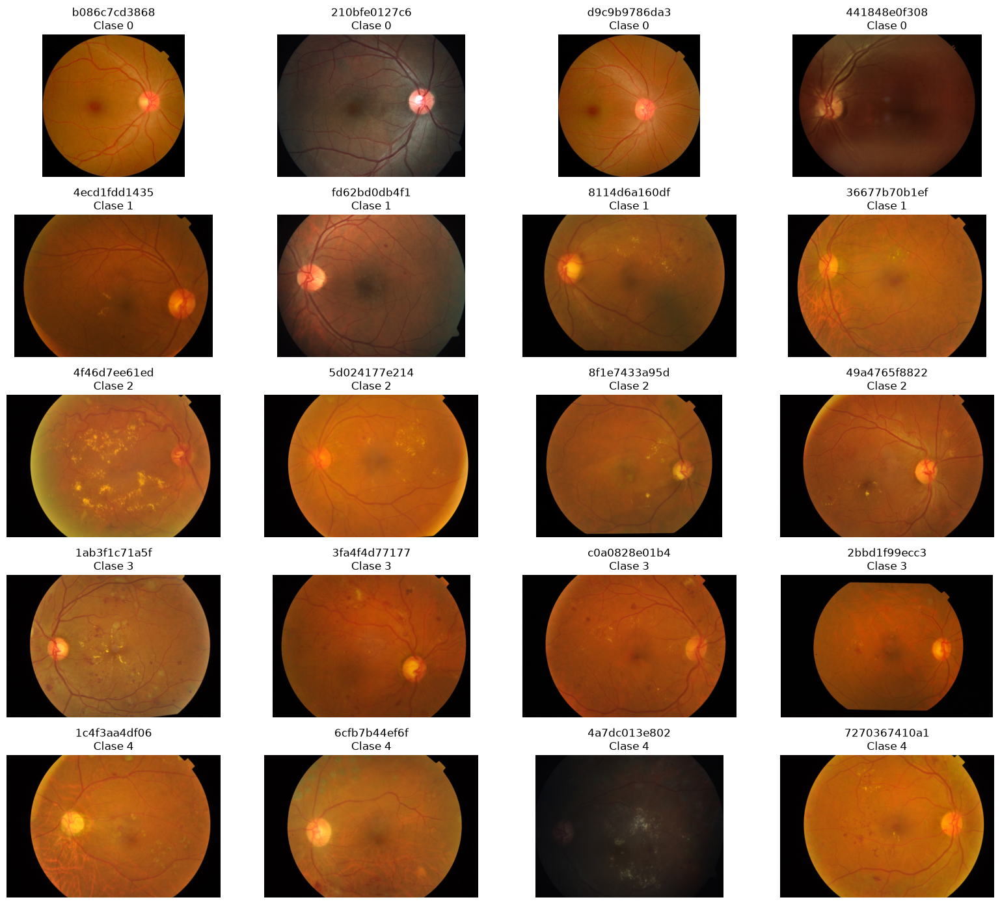

In [60]:
import matplotlib.pyplot as plt

samples_per_class = 4
random_seed = 42

fig, axes = plt.subplots(
    5,
    samples_per_class,
    figsize=(16, 14)
)

for diagnosis in range(5):
    class_df = clean_df[
        clean_df["diagnosis"] == diagnosis
    ]
    sample_df = class_df.sample(
        n=samples_per_class,
        random_state=random_seed
    )
    for col, (_, row) in enumerate(
        sample_df.iterrows()
    ):
        image_path = Path(
            row["image_path"]
        )
        with Image.open(image_path) as img:
            image = np.array(
                img.convert("RGB")
            )
        axes[
            diagnosis,
            col
        ].imshow(image)
        axes[
            diagnosis,
            col
        ].axis("off")
        axes[
            diagnosis,
            col
        ].set_title(
            f"{row['id_code']}\n"
            f"Clase {diagnosis}"
        )
    axes[
        diagnosis,
        0
    ].set_ylabel(
        class_names[diagnosis],
        fontsize=12
    )

plt.tight_layout()
plt.show()

### 12.1. Aspectos visuales a inspeccionar

Durante la exploración se consideran principalmente:

- presencia y tamaño de regiones negras alrededor del campo retinal;
- posición y escala de la retina dentro de la imagen;
- variaciones de iluminación, brillo y contraste;
- diferencias de resolución y relación de aspecto;
- posibles desenfoques, sobreexposición o subexposición;
- presencia de artefactos visuales;
- variabilidad visual dentro de una misma clase diagnóstica.

Esta inspección no modifica todavía las imágenes. Su objetivo es orientar
la definición posterior de un preprocesamiento común y reproducible para
las arquitecturas candidatas.

### 12.2. Hallazgos de la exploración visual

La inspección visual del conjunto depurado evidencia una variabilidad
considerable en las condiciones de adquisición de las retinografías.

Se observan diferencias en la extensión de las regiones negras alrededor
del campo retinal, en la posición y escala de la retina dentro de la
imagen, así como variaciones importantes de iluminación, exposición,
contraste y tonalidad.

También se identifican imágenes con menor luminosidad o contraste y
diferencias en el grado de ocupación del campo retinal dentro del
encuadre.

Estas observaciones, junto con la heterogeneidad de resoluciones
identificada previamente, justifican la definición posterior de un
procedimiento común de preprocesamiento que preserve la geometría de la
retina y reduzca las regiones no informativas.

En esta etapa no se modifica ninguna imagen ni se establece todavía una
técnica definitiva de realce o normalización.

## 13. Screening de posibles duplicados visuales

Después de eliminar los duplicados binariamente idénticos mediante
SHA-256, se realiza un análisis adicional para detectar imágenes
visualmente muy similares cuyo archivo binario no sea exactamente igual.

Para ello se utiliza un hash perceptual (pHash), diseñado para conservar
información estructural de la imagen incluso frente a pequeñas
transformaciones.

Este análisis se utiliza exclusivamente como mecanismo de screening.
Las imágenes detectadas como similares no se eliminan automáticamente,
ya que retinografías diferentes pueden compartir características
visuales globales.

Cualquier pareja candidata debe ser revisada antes de tomar una decisión
de depuración.

### 13.1. Implementación del algoritmo de hash perceptual (pHash)

Definición de la función `compute_phash` basada en la Transformada de Coseno Discreta (DCT) sobre imágenes en escala de grises reescaladas, excluyendo el coeficiente DC para reducir la dependencia de la iluminación global.

In [61]:
import cv2
import numpy as np

def compute_phash(
    image_path,
    hash_size=8,
    highfreq_factor=4
):
    image = cv2.imread(
        str(image_path),
        cv2.IMREAD_GRAYSCALE
    )
    if image is None:
        raise ValueError(
            f"No se pudo leer: {image_path}"
        )
    size = hash_size * highfreq_factor
    image = cv2.resize(
        image,
        (size, size),
        interpolation=cv2.INTER_AREA
    )
    image = np.float32(image)
    dct = cv2.dct(image)
    low_freq = dct[
        :hash_size,
        :hash_size
    ]
    # Se excluye el coeficiente DC para calcular
    # un valor central menos dependiente del brillo global.
    median_value = np.median(
        low_freq.flatten()[1:]
    )
    bits = (
        low_freq > median_value
    ).flatten()
    hash_value = 0
    for bit in bits:
        hash_value = (
            hash_value << 1
        ) | int(bit)
    return hash_value

### 13.2. Cálculo de pHash sobre las 3504 observaciones del conjunto limpio

Iteración sobre el conjunto depurado para extraer y registrar la huella perceptual de cada imagen.

In [62]:
phash_rows = []
for i, row in clean_df.iterrows():
    image_path = Path(
        row["image_path"]
    )
    phash_value = compute_phash(
        image_path
    )
    phash_rows.append(
        {
            "id_code":
                row["id_code"],
            "diagnosis":
                int(row["diagnosis"]),
            "phash":
                phash_value
        }
    )
    if (
        (len(phash_rows) % 500 == 0)
        or
        (len(phash_rows) == len(clean_df))
    ):
        print(
            f"Procesadas: "
            f"{len(phash_rows)}/"
            f"{len(clean_df)}"
        )
phash_df = pd.DataFrame(
    phash_rows
)
print(
    "Hashes perceptuales generados:",
    len(phash_df)
)

Procesadas: 500/3504
Procesadas: 1000/3504
Procesadas: 1500/3504
Procesadas: 2000/3504
Procesadas: 2500/3504
Procesadas: 3000/3504
Procesadas: 3500/3504
Procesadas: 3504/3504
Hashes perceptuales generados: 3504


### 13.3. Definición de la métrica de distancia de Hamming

Cálculo del número de bits disímiles entre dos valores de hash para medir el grado de divergencia estructural entre imágenes.

In [63]:
def hamming_distance(
    hash_a,
    hash_b
):
    return (
        int(hash_a)
        ^ int(hash_b)
    ).bit_count()

### 13.4. Búsqueda exhaustiva de parejas candidatas por umbral de proximidad

Comparación de todos los pares únicos posibles (~6.1 millones de combinaciones) identificando aquellos cuya distancia de Hamming sea menor o igual a 4 bits.

In [64]:
PHASH_THRESHOLD = 4
candidate_pairs = []
phash_records = phash_df.to_dict("records")
n = len(phash_records)

for i in range(n):
    hash_i = phash_records[i]["phash"]
    for j in range(
        i + 1,
        n
    ):
        distance = hamming_distance(
            hash_i,
            phash_records[j]["phash"]
        )
        if distance <= PHASH_THRESHOLD:
            candidate_pairs.append(
                {
                    "id_code_1":
                        phash_records[i][
                            "id_code"
                        ],
                    "diagnosis_1":
                        phash_records[i][
                            "diagnosis"
                        ],
                    "id_code_2":
                        phash_records[j][
                            "id_code"
                        ],
                    "diagnosis_2":
                        phash_records[j][
                            "diagnosis"
                        ],
                    "phash_distance":
                        distance
                }
            )

phash_candidates_df = pd.DataFrame(
    candidate_pairs
)
print(
    "Parejas candidatas:",
    len(phash_candidates_df)
)

Parejas candidatas: 2266


### 13.5. Inspección de parejas candidatas encontradas

Ordenamiento por cercanía estructural e identificador para visualizar las parejas detectadas con menor distancia perceptual.

In [65]:
if len(phash_candidates_df) > 0:
    phash_candidates_df = (
        phash_candidates_df
        .sort_values(
            [
                "phash_distance",
                "id_code_1",
                "id_code_2"
            ]
        )
        .reset_index(
            drop=True
        )
    )
    display(
        phash_candidates_df.head(30)
    )
else:
    print(
        "No se encontraron candidatos "
        "con el umbral utilizado."
    )

,id_code_1,diagnosis_1,id_code_2,diagnosis_2,phash_distance
0,0243404e8a00,4,3b018e8b7303,3,0
1,0243404e8a00,4,3ddb86eb530e,2,0
2,0a4e1a29ffff,0,1b862fb6f65d,0,0
3,16ce555748d8,4,4d9fc85a8259,3,0
4,1b398c0494d1,0,81914ceb4e74,0,0
5,26fc2358a38d,0,59bd19c1c5bb,0,0
6,28dc010a0780,0,7e980424868e,0,0
7,28dc010a0780,0,b10fca20c885,0,0
8,29f44aea93a4,2,7e6e90a93aa5,2,0
9,2b48daf24be0,3,9a94e0316ee3,3,0


### 13.6. Persistencia de resultados del screening perceptual

Almacenamiento del listado de parejas candidatas detectadas mediante pHash en el directorio de resultados de auditoría.

In [66]:
PHASH_CANDIDATES_PATH = (
    RESULTS_DIR
    / "candidatos_similitud_phash.csv"
)
phash_candidates_df.to_csv(
    PHASH_CANDIDATES_PATH,
    index=False
)
print(
    "Resultados guardados en:",
    PHASH_CANDIDATES_PATH
)

Resultados guardados en: /mnt/c/Users/SeuNg720/Documents/TP1-RetiScan/results/RD/data_audit/candidatos_similitud_phash.csv


### 13.4. Distribución de candidatos según distancia perceptual

Se analiza la distribución de las parejas candidatas según la distancia
de Hamming obtenida mediante pHash.

Debido a la similitud estructural inherente entre retinografías, una
distancia perceptual baja no se considera evidencia suficiente de
duplicación. Este análisis se utiliza únicamente para priorizar los
casos que requieren una comprobación adicional.

In [67]:
phash_distance_distribution = (
    phash_candidates_df[
        "phash_distance"
    ]
    .value_counts()
    .sort_index()
    .rename_axis(
        "phash_distance"
    )
    .reset_index(
        name="cantidad_parejas"
    )
)
display(
    phash_distance_distribution
)

,phash_distance,cantidad_parejas
0,0,23
1,2,267
2,4,1976


### 13.4.1. Concordancia diagnóstica entre parejas candidatas

Evaluación de la coincidencia o discrepancia en las etiquetas de Retinopatía Diabética entre las parejas detectadas con alta similitud perceptual.

In [68]:
phash_candidates_df[
    "same_diagnosis"
] = (
    phash_candidates_df[
        "diagnosis_1"
    ]
    ==
    phash_candidates_df[
        "diagnosis_2"
    ]
)
diagnosis_agreement = (
    phash_candidates_df[
        "same_diagnosis"
    ]
    .value_counts()
    .rename_axis(
        "same_diagnosis"
    )
    .reset_index(
        name="cantidad_parejas"
    )
)
display(
    diagnosis_agreement
)

,same_diagnosis,cantidad_parejas
0,True,1894
1,False,372


### 13.4.2. Inspección prioritaria de candidatos con distancia mínima

Visualización de las parejas con distancia perceptual extrema (distancia pHash ≤ 1 bit) para identificar casos de cuasi-identidad o alta proximidad visual.

In [69]:
display(
    phash_candidates_df[
        phash_candidates_df[
            "phash_distance"
        ] <= 1
    ].head(30)
)

,id_code_1,diagnosis_1,id_code_2,diagnosis_2,phash_distance,same_diagnosis
0,0243404e8a00,4,3b018e8b7303,3,0,False
1,0243404e8a00,4,3ddb86eb530e,2,0,False
2,0a4e1a29ffff,0,1b862fb6f65d,0,0,True
3,16ce555748d8,4,4d9fc85a8259,3,0,False
4,1b398c0494d1,0,81914ceb4e74,0,0,True
5,26fc2358a38d,0,59bd19c1c5bb,0,0,True
6,28dc010a0780,0,7e980424868e,0,0,True
7,28dc010a0780,0,b10fca20c885,0,0,True
8,29f44aea93a4,2,7e6e90a93aa5,2,0,True
9,2b48daf24be0,3,9a94e0316ee3,3,0,True


### 13.5. Priorización de candidatos según distancia perceptual

Los candidatos detectados mediante pHash se clasifican según su distancia
de Hamming. Las parejas con distancia igual a cero representan el nivel
máximo de similitud perceptual producido por este descriptor.

Debido a que pHash resume globalmente la estructura visual de una imagen,
una coincidencia perceptual no constituye por sí misma evidencia de que dos
archivos representen la misma retinografía.

Por este motivo, los candidatos más próximos serán sometidos a una segunda
comparación cuantitativa y posteriormente a inspección visual.

In [70]:
phash_distance_diagnosis = pd.crosstab(
    phash_candidates_df["phash_distance"],
    phash_candidates_df["same_diagnosis"]
)
phash_distance_diagnosis.columns = [
    "diagnostico_diferente",
    "mismo_diagnostico"
]
display(
    phash_distance_diagnosis
)

,diagnostico_diferente,mismo_diagnostico
phash_distance,,
0,8,15
2,49,218
4,315,1661


### 13.6. Comparación secundaria de candidatos altamente similares

Se aplica una segunda medida de similitud a las parejas con distancia
pHash menor o igual a 2.

Para reducir el efecto de los márgenes negros y las diferentes resoluciones,
se extrae aproximadamente el campo retinal, se redimensiona la región
resultante a una dimensión común y se normaliza su intensidad.

Este procesamiento se utiliza únicamente para la auditoría de duplicados
y no corresponde al preprocesamiento definitivo de los modelos.

In [71]:
def prepare_image_for_similarity(
    image_path,
    output_size=256
):
    image = cv2.imread(
        str(image_path),
        cv2.IMREAD_GRAYSCALE
    )
    if image is None:
        raise ValueError(
            f"No se pudo leer: {image_path}"
        )
    # Región no negra aproximada
    mask = image > 10
    coords = np.argwhere(mask)
    if len(coords) > 0:
        y_min, x_min = coords.min(axis=0)
        y_max, x_max = coords.max(axis=0)
        image = image[
            y_min:y_max + 1,
            x_min:x_max + 1
        ]
    image = cv2.resize(
        image,
        (output_size, output_size),
        interpolation=cv2.INTER_AREA
    )
    image = image.astype(
        np.float32
    )
    # Estandarización para reducir diferencias
    # globales de brillo y contraste
    mean = image.mean()
    std = image.std()
    if std > 1e-6:
        image = (
            image - mean
        ) / std
    else:
        image = image - mean
    return image

### 13.6.1. Definición de similitud por correlación normalizada

Cálculo del producto punto normalizado (coseno del ángulo) entre vectores de píxeles estandarizados para evaluar la concordancia estructural entre dos imágenes preparadas.

In [72]:
def normalized_similarity(
    image_a,
    image_b
):
    a = image_a.flatten()
    b = image_b.flatten()
    denominator = (
        np.linalg.norm(a)
        * np.linalg.norm(b)
    )
    if denominator == 0:
        return 0.0
    return float(
        np.dot(a, b)
        / denominator
    )

### 13.6.2. Filtrado de candidatos con alta proximidad perceptual (pHash ≤ 2)

Aislamiento del subconjunto de candidatos prioritarios que presentan una distancia de Hamming menor o igual a 2 bits.

In [73]:
strong_candidates_df = (
    phash_candidates_df[
        phash_candidates_df[
            "phash_distance"
        ] <= 2
    ]
    .copy()
    .reset_index(drop=True)
)
print(
    "Candidatos pHash <= 2:",
    len(strong_candidates_df)
)

Candidatos pHash <= 2: 290


### 13.7. Cálculo de similitud secundaria sobre candidatos fuertes

Extracción del campo retinal normalizado y cálculo de la correlación normalizada para cada una de las 290 parejas candidatas prioritarias.

In [74]:
similarity_scores = []
for i, row in strong_candidates_df.iterrows():
    path_1 = (
        TRAIN_IMAGES_DIR
        / f"{row['id_code_1']}.png"
    )
    path_2 = (
        TRAIN_IMAGES_DIR
        / f"{row['id_code_2']}.png"
    )
    image_1 = prepare_image_for_similarity(
        path_1
    )
    image_2 = prepare_image_for_similarity(
        path_2
    )
    similarity = normalized_similarity(
        image_1,
        image_2
    )
    similarity_scores.append(
        similarity
    )
strong_candidates_df[
    "normalized_similarity"
] = similarity_scores

### 13.7.1. Inspección y estadísticas descriptivas de similitud normalizada

Ordenamiento decreciente según correlación normalizada para identificar las parejas con mayor grado de coincidencia visual y análisis estadístico de la distribución de puntajes.

In [75]:
strong_candidates_df = (
    strong_candidates_df
    .sort_values(
        [
            "normalized_similarity",
            "phash_distance"
        ],
        ascending=[
            False,
            True
        ]
    )
    .reset_index(drop=True)
)
display(
    strong_candidates_df.head(30)
)
print(
    strong_candidates_df[
        "normalized_similarity"
    ].describe()
)

,id_code_1,diagnosis_1,id_code_2,diagnosis_2,phash_distance,same_diagnosis,normalized_similarity
0,2b48daf24be0,3,9a94e0316ee3,3,0,True,0.999987
1,16ce555748d8,4,4d9fc85a8259,3,0,False,0.999980
2,cd93a472e5cd,4,d035c2bd9104,3,0,False,0.999979
3,b019a49787c1,3,e1fb532f55df,3,0,True,0.999976
4,3b018e8b7303,3,3ddb86eb530e,2,0,False,0.999974
5,33778d136069,3,4ccfa0b4e96c,4,0,False,0.999972
6,8688f3d0fcaf,3,bfefa7344e7d,4,2,False,0.999956
7,3435fd8675a2,3,c62585bd68fb,4,0,False,0.999955
8,0243404e8a00,4,3ddb86eb530e,2,0,False,0.999830
9,0243404e8a00,4,3b018e8b7303,3,0,False,0.999826


count    290.000000
mean       0.958510
std        0.058633
min        0.563986
25%        0.964734
50%        0.979418
75%        0.985025
max        0.999987
Name: normalized_similarity, dtype: float64


### 13.8. Distribución de candidatos según similitud normalizada

Se cuantifica la cantidad de parejas que superan distintos niveles de
similitud normalizada.

Estos valores se utilizan únicamente para priorizar la revisión visual
y no constituyen criterios automáticos de eliminación.

In [76]:
similarity_thresholds = [
    0.95,
    0.97,
    0.98,
    0.99,
    0.995,
    0.999
]
threshold_summary = []
for threshold in similarity_thresholds:
    subset = strong_candidates_df[
        strong_candidates_df[
            "normalized_similarity"
        ] >= threshold
    ]
    threshold_summary.append(
        {
            "threshold": threshold,
            "cantidad_parejas": len(subset),
            "mismo_diagnostico": int(
                subset[
                    "same_diagnosis"
                ].sum()
            ),
            "diagnostico_diferente": int(
                (~subset[
                    "same_diagnosis"
                ]).sum()
            )
        }
    )
threshold_summary_df = pd.DataFrame(
    threshold_summary
)
display(
    threshold_summary_df
)

,threshold,cantidad_parejas,mismo_diagnostico,diagnostico_diferente
0,0.950,237,198,39
1,0.970,203,174,29
2,0.980,140,113,27
3,0.990,22,10,12
4,0.995,11,2,9
5,0.999,11,2,9


### 13.9. Revisión visual de candidatos de máxima similitud

Las parejas con mayor similitud normalizada son inspeccionadas
visualmente para determinar si representan realmente la misma
retinografía o simplemente imágenes diferentes con una estructura
global similar.

La decisión de considerar una pareja como near-duplicate no se basa
exclusivamente en pHash ni en la similitud normalizada.

In [77]:
def show_candidate_pairs(
    df,
    n_pairs=10
):
    sample = df.head(n_pairs).reset_index(drop=True)
    n_pairs = len(sample)
    fig, axes = plt.subplots(
        n_pairs,
        2,
        figsize=(10, 4 * n_pairs)
    )
    if n_pairs == 1:
        axes = np.array(
            [axes]
        )
    for i, row in sample.iterrows():
        id_1 = row["id_code_1"]
        id_2 = row["id_code_2"]
        path_1 = (
            TRAIN_IMAGES_DIR
            / f"{id_1}.png"
        )
        path_2 = (
            TRAIN_IMAGES_DIR
            / f"{id_2}.png"
        )
        with Image.open(path_1) as img:
            image_1 = np.array(
                img.convert("RGB")
            )
        with Image.open(path_2) as img:
            image_2 = np.array(
                img.convert("RGB")
            )
        axes[i, 0].imshow(
            image_1
        )
        axes[i, 1].imshow(
            image_2
        )
        axes[i, 0].axis("off")
        axes[i, 1].axis("off")
        axes[i, 0].set_title(
            f"{id_1}\n"
            f"Clase {row['diagnosis_1']}"
        )
        axes[i, 1].set_title(
            f"{id_2}\n"
            f"Clase {row['diagnosis_2']}\n"
            f"pHash={row['phash_distance']} | "
            f"Sim={row['normalized_similarity']:.6f}"
        )
    plt.tight_layout()
    plt.show()

### 13.9.1. Visualización comparativa de las 12 parejas con mayor correlación

Inspección gráfica lado a lado de las 12 parejas de mayor puntaje para evaluar visualmente si corresponden a la misma retinografía con pequeñas variaciones o si son ojos distintos con apariencia similar.

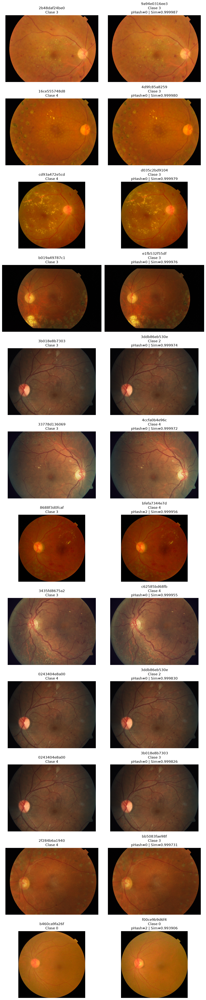

In [78]:
show_candidate_pairs(
    strong_candidates_df,
    n_pairs=12
)

### 13.10. Revisión visual ampliada de candidatos de alta similitud

A partir de la distribución observada se seleccionan para inspección visual
todas las parejas con similitud normalizada mayor o igual a 0.99.

Este umbral se utiliza únicamente para limitar la revisión manual a un
número manejable de candidatos y no constituye por sí mismo un criterio
automático de eliminación.

La confirmación de un near-duplicate requiere verificar coincidencias
anatómicas específicas, incluyendo la posición del disco óptico, el patrón
vascular, las bifurcaciones y las lesiones retinianas.

In [79]:
review_candidates_df = (
    strong_candidates_df[
        strong_candidates_df[
            "normalized_similarity"
        ] >= 0.99
    ]
    .copy()
    .reset_index(drop=True)
)
print(
    "Parejas para revisión visual:",
    len(review_candidates_df)
)

Parejas para revisión visual: 22


### 13.10.1. Inspección visual de las parejas restantes con similitud ≥ 0.99

Visualización de las 10 parejas complementarias del subconjunto de alta similitud para completar la revisión de los 22 casos seleccionados.

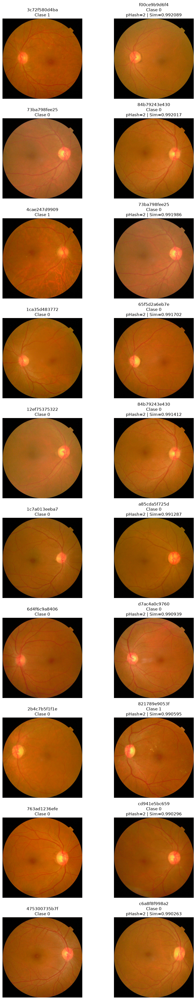

In [80]:
remaining_candidates_df = (
    review_candidates_df
    .iloc[12:]
    .reset_index(drop=True)
)
show_candidate_pairs(
    remaining_candidates_df,
    n_pairs=len(
        remaining_candidates_df
    )
)

### 13.11. Verificación geométrica mediante características locales

Las parejas candidatas seleccionadas por pHash y similitud normalizada
son sometidas a una comprobación adicional mediante características
locales SIFT.

A diferencia de las métricas globales anteriores, esta etapa evalúa si
existen puntos anatómicos locales coincidentes entre ambas imágenes y
si dichos puntos son geométricamente consistentes mediante una
transformación homográfica estimada con RANSAC.

Este análisis se utiliza como apoyo a la revisión visual y no como un
criterio automático aislado de eliminación.

In [81]:
def sift_geometric_similarity(
    image_path_1,
    image_path_2,
    ratio_threshold=0.75
):
    img1 = cv2.imread(
        str(image_path_1),
        cv2.IMREAD_GRAYSCALE
    )
    img2 = cv2.imread(
        str(image_path_2),
        cv2.IMREAD_GRAYSCALE
    )
    if img1 is None or img2 is None:
        raise ValueError("Error al leer imágenes para SIFT.")

    sift = cv2.SIFT_create()
    kp1, des1 = sift.detectAndCompute(img1, None)
    kp2, des2 = sift.detectAndCompute(img2, None)

    if des1 is None or des2 is None or len(des1) < 2 or len(des2) < 2:
        return {
            "good_matches": 0,
            "inliers": 0,
            "inlier_ratio": 0.0
        }

    matcher = cv2.BFMatcher(cv2.NORM_L2)
    raw_matches = matcher.knnMatch(des1, des2, k=2)

    good_matches = []
    for pair in raw_matches:
        if len(pair) == 2:
            m, n = pair
            if m.distance < ratio_threshold * n.distance:
                good_matches.append(m)

    if len(good_matches) < 4:
        return {
            "good_matches": len(good_matches),
            "inliers": 0,
            "inlier_ratio": 0.0
        }

    src_pts = np.float32(
        [
            kp1[m.queryIdx].pt
            for m in good_matches
        ]
    ).reshape(-1, 1, 2)
    dst_pts = np.float32(
        [
            kp2[m.trainIdx].pt
            for m in good_matches
        ]
    ).reshape(-1, 1, 2)

    _, mask = cv2.findHomography(
        src_pts,
        dst_pts,
        cv2.RANSAC,
        5.0
    )
    if mask is None:
        return {
            "good_matches":
                len(good_matches),
            "inliers": 0,
            "inlier_ratio": 0.0
        }
    inliers = int(
        mask.ravel().sum()
    )
    inlier_ratio = (
        inliers
        / len(good_matches)
    )
    return {
        "good_matches":
            len(good_matches),
        "inliers":
            inliers,
        "inlier_ratio":
            inlier_ratio
    }

### 13.11.1. Evaluación de correspondencias locales sobre las 22 parejas prioritarias

Cálculo de coincidencias SIFT, inliers homográficos y ratio de consistencia geométrica para cada una de las 22 parejas de candidatos inspeccionados.

In [82]:
sift_rows = []
for _, row in review_candidates_df.iterrows():
    path_1 = (
        TRAIN_IMAGES_DIR
        / f"{row['id_code_1']}.png"
    )
    path_2 = (
        TRAIN_IMAGES_DIR
        / f"{row['id_code_2']}.png"
    )
    result = sift_geometric_similarity(
        path_1,
        path_2
    )
    sift_rows.append(
        {
            "id_code_1":
                row["id_code_1"],
            "diagnosis_1":
                row["diagnosis_1"],
            "id_code_2":
                row["id_code_2"],
            "diagnosis_2":
                row["diagnosis_2"],
            "phash_distance":
                row["phash_distance"],
            "normalized_similarity":
                row[
                    "normalized_similarity"
                ],
            "good_matches":
                result["good_matches"],
            "inliers":
                result["inliers"],
            "inlier_ratio":
                result["inlier_ratio"]
        }
    )

sift_review_df = pd.DataFrame(
    sift_rows
)
sift_review_df = (
    sift_review_df
    .sort_values(
        [
            "inlier_ratio",
            "inliers"
        ],
        ascending=False
    )
    .reset_index(drop=True)
)
display(
    sift_review_df
)

,id_code_1,diagnosis_1,id_code_2,diagnosis_2,phash_distance,normalized_similarity,good_matches,inliers,inlier_ratio
0,3435fd8675a2,3,c62585bd68fb,4,0,0.999955,131,131,1.000000
1,2f284b6a1940,4,bb5083fae98f,3,0,0.999731,77,77,1.000000
2,16ce555748d8,4,4d9fc85a8259,3,0,0.999980,60,60,1.000000
3,2b48daf24be0,3,9a94e0316ee3,3,0,0.999987,57,57,1.000000
4,0243404e8a00,4,3b018e8b7303,3,0,0.999826,32,32,1.000000
5,cd93a472e5cd,4,d035c2bd9104,3,0,0.999979,253,252,0.996047
6,b019a49787c1,3,e1fb532f55df,3,0,0.999976,129,128,0.992248
7,33778d136069,3,4ccfa0b4e96c,4,0,0.999972,120,119,0.991667
8,8688f3d0fcaf,3,bfefa7344e7d,4,2,0.999956,112,110,0.982143
9,3b018e8b7303,3,3ddb86eb530e,2,0,0.999974,34,33,0.970588


### 13.12. Confirmación de near-duplicates mediante evidencia combinada

La revisión visual y la verificación geométrica mostraron una separación
clara entre un subconjunto de parejas altamente coincidentes y el resto
de candidatos.

Se consideran near-duplicates confirmados aquellos pares que cumplen
simultáneamente:

- similitud normalizada mayor o igual a 0.999;
- ratio de inliers RANSAC mayor o igual a 0.95;
- al menos 30 correspondencias SIFT válidas.

Estos criterios se emplean de manera conjunta para reducir falsos
positivos derivados de la similitud estructural natural entre
retinografías.

In [83]:
confirmed_near_pairs_df = (
    sift_review_df[
        (
            sift_review_df[
                "normalized_similarity"
            ] >= 0.999
        )
        &
        (
            sift_review_df[
                "inlier_ratio"
            ] >= 0.95
        )
        &
        (
            sift_review_df[
                "good_matches"
            ] >= 30
        )
    ]
    .copy()
    .reset_index(drop=True)
)
print(
    "Parejas near-duplicate confirmadas:",
    len(confirmed_near_pairs_df)
)
display(
    confirmed_near_pairs_df
)

Parejas near-duplicate confirmadas: 11


,id_code_1,diagnosis_1,id_code_2,diagnosis_2,phash_distance,normalized_similarity,good_matches,inliers,inlier_ratio
0,3435fd8675a2,3,c62585bd68fb,4,0,0.999955,131,131,1.000000
1,2f284b6a1940,4,bb5083fae98f,3,0,0.999731,77,77,1.000000
2,16ce555748d8,4,4d9fc85a8259,3,0,0.999980,60,60,1.000000
3,2b48daf24be0,3,9a94e0316ee3,3,0,0.999987,57,57,1.000000
4,0243404e8a00,4,3b018e8b7303,3,0,0.999826,32,32,1.000000
5,cd93a472e5cd,4,d035c2bd9104,3,0,0.999979,253,252,0.996047
6,b019a49787c1,3,e1fb532f55df,3,0,0.999976,129,128,0.992248
7,33778d136069,3,4ccfa0b4e96c,4,0,0.999972,120,119,0.991667
8,8688f3d0fcaf,3,bfefa7344e7d,4,2,0.999956,112,110,0.982143
9,3b018e8b7303,3,3ddb86eb530e,2,0,0.999974,34,33,0.970588


### 13.13. Agrupamiento de imágenes conectadas mediante Union-Find

Debido a que un mismo identificador puede formar parte de más de una pareja confirmada, se modelan las relaciones como componentes conexas utilizando la estructura de datos Union-Find para conformar grupos cerrados de duplicados visuales.

In [84]:
parent = {}

def find(x):
    if parent[x] != x:
        parent[x] = find(
            parent[x]
        )
    return parent[x]

def union(a, b):
    if a not in parent:
        parent[a] = a
    if b not in parent:
        parent[b] = b
    root_a = find(a)
    root_b = find(b)
    if root_a != root_b:
        parent[root_b] = root_a

for _, row in (
    confirmed_near_pairs_df
    .iterrows()
):
    union(
        row["id_code_1"],
        row["id_code_2"]
    )

### 13.13.1. Extracción y consolidación de grupos conexos de near-duplicates

Recuperación de los grupos disjuntos a partir de los representantes raíz de Union-Find y listado de identificadores asociados a cada grupo.

In [85]:
near_groups = {}
for image_id in parent:
    root = find(
        image_id
    )
    near_groups.setdefault(
        root,
        []
    ).append(
        image_id
    )
near_groups = list(
    near_groups.values()
)
print(
    "Grupos near-duplicate:",
    len(near_groups)
)
for i, group in enumerate(
    near_groups,
    start=1
):
    print(
        f"Grupo {i}:",
        sorted(group)
    )

Grupos near-duplicate: 9
Grupo 1: ['3435fd8675a2', 'c62585bd68fb']
Grupo 2: ['2f284b6a1940', 'bb5083fae98f']
Grupo 3: ['16ce555748d8', '4d9fc85a8259']
Grupo 4: ['2b48daf24be0', '9a94e0316ee3']
Grupo 5: ['0243404e8a00', '3b018e8b7303', '3ddb86eb530e']
Grupo 6: ['cd93a472e5cd', 'd035c2bd9104']
Grupo 7: ['b019a49787c1', 'e1fb532f55df']
Grupo 8: ['33778d136069', '4ccfa0b4e96c']
Grupo 9: ['8688f3d0fcaf', 'bfefa7344e7d']


### 13.13.2. Evaluación de consistencia diagnóstica en grupos near-duplicate

Cruce de los grupos conexos con las etiquetas diagnósticas de `clean_df` para determinar si cada grupo posee diagnósticos concordantes o conflictivos.

In [86]:
near_group_rows = []
for group_id, group in enumerate(
    near_groups,
    start=1
):
    group_info = (
        clean_df[
            clean_df[
                "id_code"
            ].isin(group)
        ][
            [
                "id_code",
                "diagnosis"
            ]
        ]
        .copy()
    )
    labels = sorted(
        group_info[
            "diagnosis"
        ].unique().tolist()
    )
    near_group_rows.append(
        {
            "group_id":
                group_id,
            "cantidad_imagenes":
                len(group),
            "ids":
                sorted(group),
            "diagnosticos":
                labels,
            "cantidad_diagnosticos":
                len(labels),
            "consistente":
                len(labels) == 1
        }
    )
near_groups_df = pd.DataFrame(
    near_group_rows
)
display(
    near_groups_df
)

,group_id,cantidad_imagenes,ids,diagnosticos,cantidad_diagnosticos,consistente
0,1,2,"[3435fd8675a2, c62585bd68fb]","[3, 4]",2,False
1,2,2,"[2f284b6a1940, bb5083fae98f]","[3, 4]",2,False
2,3,2,"[16ce555748d8, 4d9fc85a8259]","[3, 4]",2,False
3,4,2,"[2b48daf24be0, 9a94e0316ee3]",[3],1,True
4,5,3,"[0243404e8a00, 3b018e8b7303, 3ddb86eb530e]","[2, 3, 4]",3,False
5,6,2,"[cd93a472e5cd, d035c2bd9104]","[3, 4]",2,False
6,7,2,"[b019a49787c1, e1fb532f55df]",[3],1,True
7,8,2,"[33778d136069, 4ccfa0b4e96c]","[3, 4]",2,False
8,9,2,"[8688f3d0fcaf, bfefa7344e7d]","[3, 4]",2,False


### 13.14. Tratamiento de los grupos near-duplicate confirmados

Los grupos de near-duplicates confirmados se tratan aplicando la misma
política utilizada para los duplicados exactos:

- Si todas las imágenes del grupo presentan la misma etiqueta diagnóstica,
  se conserva un único representante y se excluyen las copias redundantes.

- Si el grupo contiene etiquetas diagnósticas diferentes, se excluyen
  todas sus imágenes debido a que no existe evidencia suficiente para
  determinar cuál de las etiquetas es la correcta.

En los grupos consistentes, el representante conservado se selecciona
determinísticamente utilizando el `id_code` lexicográficamente menor.

In [87]:
near_conflicting_ids = set()
near_redundant_ids = set()
near_kept_ids = set()

for group in near_groups:
    group_info = (
        clean_df[
            clean_df["id_code"].isin(group)
        ][
            [
                "id_code",
                "diagnosis"
            ]
        ]
        .copy()
    )
    labels = sorted(
        group_info["diagnosis"]
        .unique()
        .tolist()
    )
    group_ids = sorted(
        group_info["id_code"]
        .tolist()
    )
    # Grupo conflictivo:
    # se excluyen todos sus integrantes
    if len(labels) > 1:
        near_conflicting_ids.update(
            group_ids
        )
    # Grupo consistente:
    # se conserva el ID lexicográficamente menor
    else:
        representative = group_ids[0]
        near_kept_ids.add(
            representative
        )
        near_redundant_ids.update(
            group_ids[1:]
        )

print(
    "Near-duplicates conflictivos a excluir:",
    len(near_conflicting_ids)
)
print(
    "Near-duplicates redundantes a excluir:",
    len(near_redundant_ids)
)
print(
    "Representantes conservados:",
    len(near_kept_ids)
)
print(
    "Exclusiones adicionales:",
    len(near_conflicting_ids)
    + len(near_redundant_ids)
)

Near-duplicates conflictivos a excluir: 15
Near-duplicates redundantes a excluir: 2
Representantes conservados: 2
Exclusiones adicionales: 17


### 13.15. Construcción del conjunto limpio definitivo

Aplicación de la depuración final sobre `clean_df` mediante la remoción de las observaciones asociadas a near-duplicates conflictivos y redundantes, consolidando el dataset experimental depurado (`final_clean_df`).

In [88]:
near_excluded_ids = (
    near_conflicting_ids
    | near_redundant_ids
)
final_clean_df = (
    clean_df[
        ~clean_df[
            "id_code"
        ].isin(
            near_excluded_ids
        )
    ]
    .copy()
    .sort_values("id_code")
    .reset_index(drop=True)
)
print(
    "Conjunto limpio provisional:",
    len(clean_df)
)
print(
    "Exclusiones near-duplicate:",
    len(near_excluded_ids)
)
print(
    "Conjunto limpio definitivo:",
    len(final_clean_df)
)
print(
    "Exclusiones totales desde APTOS original:",
    len(train_df)
    - len(final_clean_df)
)

Conjunto limpio provisional: 3504
Exclusiones near-duplicate: 17
Conjunto limpio definitivo: 3487
Exclusiones totales desde APTOS original: 175


### 13.16. Trazabilidad de exclusiones por near-duplicates

Documentación granular de cada observación descartada por duplicación visual, registrando el motivo específico de exclusión (`conflicting_near_duplicate` o `redundant_consistent_near_duplicate`).

In [89]:
near_exclusion_rows = []

for image_id in sorted(
    near_conflicting_ids
):
    row = clean_df[
        clean_df["id_code"]
        == image_id
    ].iloc[0]
    near_exclusion_rows.append(
        {
            "id_code":
                image_id,
            "diagnosis":
                int(
                    row["diagnosis"]
                ),
            "sha256":
                row["sha256"],
            "exclusion_reason":
                "conflicting_near_duplicate"
        }
    )

for image_id in sorted(
    near_redundant_ids
):
    row = clean_df[
        clean_df["id_code"]
        == image_id
    ].iloc[0]
    near_exclusion_rows.append(
        {
            "id_code":
                image_id,
            "diagnosis":
                int(
                    row["diagnosis"]
                ),
            "sha256":
                row["sha256"],
            "exclusion_reason":
                "redundant_consistent_near_duplicate"
        }
    )

near_excluded_df = pd.DataFrame(
    near_exclusion_rows
)
display(
    near_excluded_df[
        "exclusion_reason"
    ].value_counts()
)
print(
    "Near-duplicates excluidos:",
    len(near_excluded_df)
)

exclusion_reason
conflicting_near_duplicate             15
redundant_consistent_near_duplicate     2
Name: count, dtype: int64

Near-duplicates excluidos: 17


### 13.16.1. Consolidación de la trazabilidad global de exclusiones

Concatenación de las exclusiones por duplicados binarios exactos con las exclusiones por near-duplicates para conformar el registro maestro de observaciones descartadas.

In [90]:
all_excluded_df = pd.concat(
    [
        excluded_df,
        near_excluded_df
    ],
    ignore_index=True
)
print(
    "Exclusiones anteriores:",
    len(excluded_df)
)
print(
    "Exclusiones near-duplicate:",
    len(near_excluded_df)
)
print(
    "Exclusiones totales:",
    len(all_excluded_df)
)

Exclusiones anteriores: 158
Exclusiones near-duplicate: 17
Exclusiones totales: 175


### 13.16.2. Persistencia de registros de exclusión y near-duplicates

Almacenamiento de la tabla consolidada de exclusiones, el listado de parejas near-duplicate confirmadas y el resumen de grupos conexos en el directorio de resultados de auditoría.

In [92]:
all_excluded_df.to_csv(
    RESULTS_DIR
    / "aptos2019_registros_excluidos_final.csv",
    index=False
)
confirmed_near_pairs_df.to_csv(
    RESULTS_DIR
    / "near_duplicates_confirmados.csv",
    index=False
)
near_groups_df.to_csv(
    RESULTS_DIR
    / "near_duplicate_groups.csv",
    index=False
)

## 14. Verificación final del conjunto depurado

Después del tratamiento de duplicados exactos, conflictos de etiquetado
y near-duplicates visualmente confirmados, se realizan verificaciones
finales de integridad sobre el conjunto resultante.

El objetivo es comprobar que el dataset definitivo:

- contiene el número esperado de observaciones;
- conserva las cinco categorías diagnósticas;
- no presenta identificadores duplicados;
- no presenta hashes SHA-256 duplicados;
- no contiene valores nulos;
- no conserva registros pertenecientes a grupos conflictivos;
- no conserva simultáneamente ambas imágenes de una pareja
  near-duplicate confirmada;
- mantiene correspondencia con los archivos físicos originales.

In [93]:
print(
    "Cantidad final:",
    len(final_clean_df)
)
print(
    "IDs únicos:",
    final_clean_df["id_code"].is_unique
)
print(
    "Hashes SHA-256 únicos:",
    final_clean_df["sha256"].is_unique
)
print(
    "Valores nulos:",
    int(
        final_clean_df.isna()
        .sum()
        .sum()
    )
)
print(
    "Clases presentes:",
    sorted(
        final_clean_df[
            "diagnosis"
        ]
        .unique()
        .tolist()
    )
)
print(
    "Hashes conflictivos exactos restantes:",
    int(
        final_clean_df[
            "sha256"
        ]
        .isin(
            conflicting_hashes
        )
        .sum()
    )
)
print(
    "IDs near-duplicate excluidos restantes:",
    int(
        final_clean_df[
            "id_code"
        ]
        .isin(
            near_excluded_ids
        )
        .sum()
    )
)

Cantidad final: 3487
IDs únicos: True
Hashes SHA-256 únicos: True
Valores nulos: 0
Clases presentes: [0, 1, 2, 3, 4]
Hashes conflictivos exactos restantes: 0
IDs near-duplicate excluidos restantes: 0


### 14.1. Verificación de que ninguna pareja confirmada sobrevivió completa

Comprobación estricta de que en ninguna de las parejas near-duplicate confirmadas coexistan ambos identificadores dentro del conjunto limpio definitivo.

In [94]:
surviving_ids = set(
    final_clean_df["id_code"]
)
confirmed_pairs_remaining = []
for _, row in (
    confirmed_near_pairs_df
    .iterrows()
):
    id_1 = row["id_code_1"]
    id_2 = row["id_code_2"]
    if (
        id_1 in surviving_ids
        and
        id_2 in surviving_ids
    ):
        confirmed_pairs_remaining.append(
            {
                "id_code_1": id_1,
                "id_code_2": id_2
            }
        )
print(
    "Parejas near-duplicate "
    "confirmadas que sobreviven completas:",
    len(
        confirmed_pairs_remaining
    )
)

Parejas near-duplicate confirmadas que sobreviven completas: 0


### 14.2. Distribución final de las cinco clases

Consolidación de frecuencias absolutas y relativas por grado de severidad clínica sobre las 3487 observaciones del conjunto depurado definitivo.

In [95]:
final_class_distribution = (
    final_clean_df[
        "diagnosis"
    ]
    .value_counts()
    .sort_index()
    .rename_axis(
        "diagnosis"
    )
    .reset_index(
        name="cantidad"
    )
)
final_class_distribution[
    "clase"
] = final_class_distribution[
    "diagnosis"
].map(
    class_names
)
final_class_distribution[
    "porcentaje"
] = (
    final_class_distribution[
        "cantidad"
    ]
    / len(final_clean_df)
    * 100
)
final_class_distribution = (
    final_class_distribution[
        [
            "diagnosis",
            "clase",
            "cantidad",
            "porcentaje"
        ]
    ]
)
display(
    final_class_distribution.round(2)
)

,diagnosis,clase,cantidad,porcentaje
0,0,Sin RD,1796,51.51
1,1,Leve,338,9.69
2,2,Moderada,921,26.41
3,3,Severa,168,4.82
4,4,Proliferativa,264,7.57


### 14.3. Verificación de correspondencia física de imágenes

Comprobación de la existencia en disco de la totalidad de archivos de imagen correspondientes a los 3487 registros de `final_clean_df`.

In [96]:
final_clean_df[
    "image_exists"
] = final_clean_df[
    "image_path"
].apply(
    lambda x:
        Path(x).exists()
)
print(
    "Imágenes esperadas:",
    len(final_clean_df)
)
print(
    "Imágenes encontradas:",
    int(
        final_clean_df[
            "image_exists"
        ].sum()
    )
)
print(
    "Imágenes faltantes:",
    int(
        (
            ~final_clean_df[
                "image_exists"
            ]
        ).sum()
    )
)

Imágenes esperadas: 3487
Imágenes encontradas: 3487
Imágenes faltantes: 0


### 14.4. Aserciones definitivas de integridad

Validación formal mediante aserciones de todas las propiedades estructurales, de unicidad, completitud, correspondencia física y trazabilidad del dataset depurado.

In [97]:
assert len(
    final_clean_df
) == 3487
assert final_clean_df[
    "id_code"
].is_unique
assert final_clean_df[
    "sha256"
].is_unique
assert (
    final_clean_df
    .isna()
    .sum()
    .sum()
) == 0
assert set(
    final_clean_df[
        "diagnosis"
    ].unique()
) == {
    0, 1, 2, 3, 4
}
assert not final_clean_df[
    "sha256"
].isin(
    conflicting_hashes
).any()
assert not final_clean_df[
    "id_code"
].isin(
    near_excluded_ids
).any()
assert len(
    confirmed_pairs_remaining
) == 0
assert final_clean_df[
    "image_exists"
].all()
assert (
    len(train_df)
    - len(final_clean_df)
) == 175
assert len(
    all_excluded_df
) == 175
print(
    "Todas las verificaciones "
    "del dataset APTOS depurado "
    "fueron superadas."
)

Todas las verificaciones del dataset APTOS depurado fueron superadas.


## 15. Persistencia del conjunto depurado definitivo

Una vez superadas todas las verificaciones de integridad, se persiste el
conjunto depurado definitivo de APTOS 2019.

Los archivos originales permanecen sin modificaciones dentro de
`raw/train_images/`. El archivo maestro generado contiene únicamente las
observaciones seleccionadas para el experimento y será utilizado como
entrada para la posterior construcción de las particiones Train,
Validation y Test.

In [98]:
METADATA_DIR = (
    APTOS_ROOT
    / "metadata"
)
METADATA_DIR.mkdir(
    parents=True,
    exist_ok=True
)
FINAL_MASTER_PATH = (
    METADATA_DIR
    / "aptos2019_master_clean.csv"
)
FINAL_DISTRIBUTION_PATH = (
    METADATA_DIR
    / "aptos2019_final_class_distribution.csv"
)
print(
    "Metadata:",
    METADATA_DIR
)

Metadata: /mnt/c/Users/SeuNg720/Documents/TP1-RetiScan/datasets/RD/aptos2019/metadata


### 15.1. Construcción de la tabla maestra con rutas relativas

Estructuración de las columnas maestras (`id_code`, `image_name`, `image_path`, `diagnosis`, `sha256`) utilizando rutas relativas reproducibles a partir de `datasets/RD/aptos2019/`.

In [99]:
master_clean_df = (
    final_clean_df[
        [
            "id_code",
            "diagnosis",
            "sha256"
        ]
    ]
    .copy()
)
master_clean_df[
    "image_name"
] = (
    master_clean_df[
        "id_code"
    ]
    + ".png"
)
master_clean_df[
    "image_path"
] = (
    "raw/train_images/"
    + master_clean_df[
        "image_name"
    ]
)
master_clean_df = (
    master_clean_df[
        [
            "id_code",
            "image_name",
            "image_path",
            "diagnosis",
            "sha256"
        ]
    ]
    .sort_values(
        "id_code"
    )
    .reset_index(
        drop=True
    )
)
display(
    master_clean_df.head()
)
print(
    "Registros del master:",
    len(master_clean_df)
)

,id_code,image_name,image_path,diagnosis,sha256
0,000c1434d8d7,000c1434d8d7.png,raw/train_images/000c1434d8d7.png,2,3f34b577a7102dddea20d2aaed76028bcf724ddb82e923...
1,001639a390f0,001639a390f0.png,raw/train_images/001639a390f0.png,4,9e4a10bcf0569bd7640ff3107601cb00c1147c44de5d3e...
2,0024cdab0c1e,0024cdab0c1e.png,raw/train_images/0024cdab0c1e.png,1,ef0bda2c21f3dbe839b4e5168fa7e52afe61e6923a56fd...
3,002c21358ce6,002c21358ce6.png,raw/train_images/002c21358ce6.png,0,c18a236541ae3d3ddbf8cf3eae991b4ff28446c5313b3d...
4,005b95c28852,005b95c28852.png,raw/train_images/005b95c28852.png,0,4af20410946f8730d1a9c13361a0b4604c5934c325890b...


Registros del master: 3487


### 15.2. Exportación de metadatos definitivos

Guardado de la tabla maestra limpia y de la distribución final de clases en el directorio `metadata/`.

In [100]:
master_clean_df.to_csv(
    FINAL_MASTER_PATH,
    index=False
)
final_class_distribution.to_csv(
    FINAL_DISTRIBUTION_PATH,
    index=False
)
print(
    "Master guardado en:",
    FINAL_MASTER_PATH
)
print(
    "Distribución guardada en:",
    FINAL_DISTRIBUTION_PATH
)

Master guardado en: /mnt/c/Users/SeuNg720/Documents/TP1-RetiScan/datasets/RD/aptos2019/metadata/aptos2019_master_clean.csv
Distribución guardada en: /mnt/c/Users/SeuNg720/Documents/TP1-RetiScan/datasets/RD/aptos2019/metadata/aptos2019_final_class_distribution.csv


## 16. Resumen reproducible de la auditoría

Consolidación de las métricas clave del proceso de depuración en formato JSON estructurado, registrando conteos de imágenes originales, descartadas por duplicación exacta y near-duplicates, y distribución final por clase.

In [101]:
import json

AUDIT_SUMMARY_PATH = (
    RESULTS_DIR
    / "aptos2019_audit_summary.json"
)

audit_summary = {
    "total_original": int(
        len(train_df)
    ),
    "total_clean": int(
        len(final_clean_df)
    ),
    "total_excluded": int(
        len(train_df)
        - len(final_clean_df)
    ),
    "exact_duplicate_groups": int(
        len(duplicate_groups_summary)
    ),
    "exact_consistent_groups": int(
        len(consistent_duplicate_groups)
    ),
    "exact_conflicting_groups": int(
        len(conflicting_duplicate_groups)
    ),
    "exact_conflicting_images": int(
        len(conflicting_images_df)
    ),
    "confirmed_near_duplicate_pairs": int(
        len(confirmed_near_pairs_df)
    ),
    "confirmed_near_duplicate_groups": int(
        len(near_groups_df)
    ),
    "near_duplicate_exclusions": int(
        len(near_excluded_df)
    ),
    "classes": {
        str(int(row["diagnosis"])): {
            "name": row["clase"],
            "count": int(row["cantidad"]),
            "percentage": float(
                row["porcentaje"]
            )
        }
        for _, row
        in final_class_distribution.iterrows()
    }
}

with open(
    AUDIT_SUMMARY_PATH,
    "w",
    encoding="utf-8"
) as f:
    json.dump(
        audit_summary,
        f,
        indent=4,
        ensure_ascii=False
    )

print(
    "Resumen de auditoría guardado en:",
    AUDIT_SUMMARY_PATH
)

Resumen de auditoría guardado en: /mnt/c/Users/SeuNg720/Documents/TP1-RetiScan/results/RD/data_audit/aptos2019_audit_summary.json


## 17. Conclusión de la auditoría

La auditoría inicial de APTOS 2019 confirmó la disponibilidad de 3662
retinografías etiquetadas correspondientes a cinco grados de severidad
de Retinopatía Diabética.

No se identificaron imágenes faltantes, archivos corruptos, valores nulos
ni identificadores repetidos. Sin embargo, el análisis de contenido
detectó duplicados exactos y casos en los que imágenes idénticas estaban
asociadas a etiquetas diagnósticas diferentes.

Tras el tratamiento de duplicados exactos y conflictos de etiquetado se
obtuvo un conjunto provisional de 3504 imágenes.

Posteriormente, un screening adicional basado en similitud perceptual,
comparación normalizada, inspección visual y verificación geométrica
mediante SIFT y RANSAC permitió identificar grupos adicionales de
near-duplicates. La aplicación de la política de depuración excluyó 17
observaciones adicionales.

El conjunto depurado definitivo quedó compuesto por **3487 imágenes**,
distribuidas en las cinco categorías diagnósticas:

- Clase 0 — Sin RD: 1796 imágenes.
- Clase 1 — Leve: 338 imágenes.
- Clase 2 — Moderada: 921 imágenes.
- Clase 3 — Severa: 168 imágenes.
- Clase 4 — Proliferativa: 264 imágenes.

El conjunto conserva un desbalance de clases, especialmente en la
categoría Severa, aspecto que deberá ser considerado posteriormente
durante el diseño del pipeline de entrenamiento.

Las imágenes originales no fueron modificadas ni eliminadas físicamente.
La selección definitiva queda registrada mediante un archivo maestro
reproducible, que servirá como entrada para la construcción de las
particiones experimentales Train, Validation y Test.